# Read road files

format: lat, lon, lrp, lat lon lrp, etc. for all unnamed columns

In [12]:
import pandas as pd
ROADS_FILE = r"_roads.tsv"

def load_roads():
    """Load roads TSV."""
    df = pd.read_csv(
        ROADS_FILE,
        sep="\t",
        engine="python",
        dtype=str  # preserve everything as string
    )
    return df

print("Loading roads...")
roads_df = load_roads()
print(roads_df.head())
print(f"Road rows: {len(roads_df)}\n")

Loading roads...
   road  lrp1                lat1        lon1    lrp2                lat2  \
0    N1  LRPS          23.7060278   90.443333   LRPSa          23.7029167   
1  N101  LRPS          23.4541389  91.2128611   LRPSa  23.461888899999998   
2  N102  LRPS          23.4789716  91.1181938   LRPSa          23.4815827   
3  N103  LRPS  23.957027800000002  91.1155278  LRP001          23.9619167   
4  N104  LRPS          23.0096667  91.3994163   LRPSa  23.009277800000003   

                lon2 Unnamed: 7          Unnamed: 8         Unnamed: 9  ...  \
0         90.4504167      LRPSb  23.702777800000003  90.45047220000001  ...   
1             91.212     LRP001  23.462944399999998         91.2118056  ...   
2         91.1167771      LRPSb          23.4866663  91.11336109999999  ...   
3  91.11361109999999    LRP001a           23.967666  91.11188890000001  ...   
4         91.3952497     LRP001          23.0093056         91.3898052  ...   

  Unnamed: 4035 Unnamed: 4036       Unnamed: 

# Read bridge files

In [2]:
BRIDGES_FILE = r"BMMS_overview.xlsx"

def load_bridges():
    """Load bridges Excel."""
    df = pd.read_excel(BRIDGES_FILE, dtype=str, engine="openpyxl")
    return df

print("Loading bridges...")
bridges_df = load_bridges()
print(bridges_df.head())
print(f"Bridge rows: {len(bridges_df)}\n")

Loading bridges...
  road      km              type  LRPName               name  length  \
0   N1     1.8       Box Culvert  LRP001a                  .    11.3   
1   N1   4.925       Box Culvert  LRP004b                  .     6.6   
2   N1   8.976  PC Girder Bridge  LRP008b  Kanch pur Bridge.  394.23   
3   N1   10.88       Box Culvert  LRP010b   NOYAPARA CULVERT     6.3   
4   N1  10.897       Box Culvert  LRP010c     ADUPUR CULVERT     6.3   

  condition structureNr                                           roadName  \
0         A      117861  Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...   
1         A      117862  Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...   
2         A      119889  Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...   
3         A      112531  Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...   
4         A      112532  Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...   

  chainage width constructionYear spans   zone circle     division  \
0      1.

## Inspection of a road with bridges

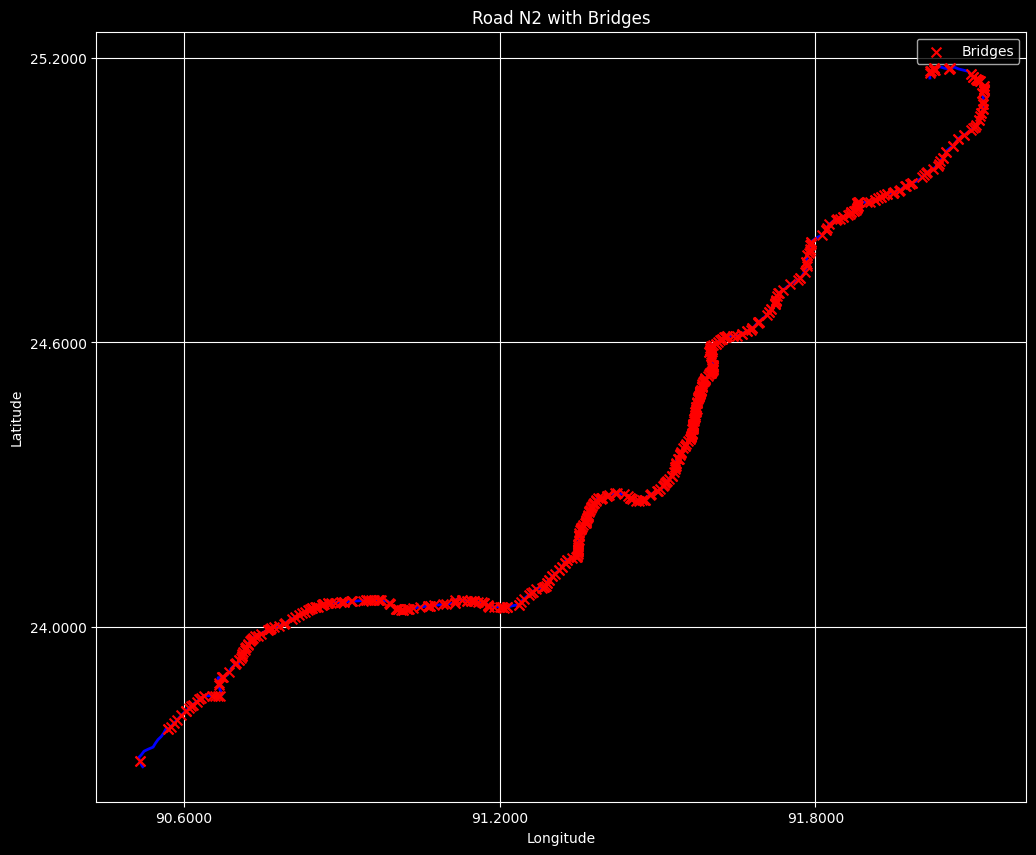

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

road_name = "N2"
road_data = roads_df[roads_df['road'] == road_name]

plt.figure(figsize=(12, 10))

for idx, row in road_data.iterrows():
    segment_coords = []
    col_idx = 1
    while col_idx + 2 < len(row):
        try:
            lat = float(row[col_idx + 1])
            lon = float(row[col_idx + 2])
            segment_coords.append((lon, lat))
        except (ValueError, TypeError):
            # Skip if value is missing or not convertible
            pass
        col_idx += 3
    
    if len(segment_coords) >= 2:
        segment_coords = np.array(segment_coords)
        plt.plot(segment_coords[:, 0], segment_coords[:, 1], color='blue', linewidth=2)

# Bridges
lat_col = 'lat'   # replace if your column name is different
lon_col = 'lon'

bridge_data = bridges_df[bridges_df['road'] == road_name]

# Convert to float and drop invalid values
bridge_coords = bridge_data[[lon_col, lat_col]].copy()
bridge_coords[lon_col] = pd.to_numeric(bridge_coords[lon_col], errors='coerce')
bridge_coords[lat_col] = pd.to_numeric(bridge_coords[lat_col], errors='coerce')
bridge_coords = bridge_coords.dropna()

# Now plot bridges
plt.scatter(bridge_coords[lon_col], bridge_coords[lat_col], color='red', marker='x', s=50, label='Bridges', zorder = 7)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Road {road_name} with Bridges')
plt.grid(True)

# Only 3 ticks
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=3))

# Format ticks
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.4f}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.4f}"))

plt.legend()
plt.show()


# Road correction algorithm

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Clean DataFrames ---
roads_df.columns = roads_df.columns.str.strip()
bridges_df.columns = bridges_df.columns.str.strip()

roads_df['road'] = roads_df['road'].astype(str).str.strip().str.upper()
bridges_df['road'] = bridges_df['road'].astype(str).str.strip().str.upper()

# --- Distance helper ---
def point_line_distance(p, a, b):
    p, a, b = np.array(p), np.array(a), np.array(b)
    if np.all(a == b):
        return np.linalg.norm(p - a)
    return np.abs(np.cross(b - a, a - p)) / np.linalg.norm(b - a)


# --- Detect wrong LRPs ---
def detect_wrong_lrps_sequences(corrected_lrps, factor_jump=6.0, factor_dev=2.0):

    n = len(corrected_lrps)
    wrong_flags = np.zeros(n, dtype=bool)

    seg_lengths = np.linalg.norm(np.diff(corrected_lrps, axis=0), axis=1)

    if len(seg_lengths) == 0:
        return wrong_flags

    median_spacing = np.median(seg_lengths)
    jump_threshold = factor_jump * median_spacing
    dev_threshold = factor_dev * median_spacing

    for i in range(1, n):
        jump = np.linalg.norm(corrected_lrps[i] - corrected_lrps[i-1])
        if jump > jump_threshold:
            wrong_flags[i-1] = True
            wrong_flags[i] = True

    for i in range(1, n-1):
        if wrong_flags[i]:
            continue
        dist = point_line_distance(corrected_lrps[i],
                                   corrected_lrps[i-1],
                                   corrected_lrps[i+1])
        if dist > dev_threshold:
            wrong_flags[i] = True

    return wrong_flags


# --- Process one road ---
def process_road(road_name, roads_df, bridges_df, factor_jump=6.0, factor_dev=2.0):
    road_data = roads_df[roads_df['road'] == road_name].copy()
    bridge_data = bridges_df[bridges_df['road'] == road_name].copy()

    if len(road_data) == 0:
        return None

    road_lrps = []
    for idx, row in road_data.iterrows():
        col_idx = 1
        while col_idx + 2 < len(row):
            lrp = row.iloc[col_idx]
            lat = row.iloc[col_idx+1]
            lon = row.iloc[col_idx+2]
            if pd.notna(lrp) and pd.notna(lat) and pd.notna(lon):
                road_lrps.append({
                    'lrp': str(lrp), 'lat': float(lat), 'lon': float(lon),
                    'col_idx': col_idx, 'row_idx': idx
                })
            col_idx += 3

    if len(road_lrps) < 3:
        return None

    lrp_names = [p['lrp'] for p in road_lrps]
    corrected_lrps = np.column_stack((
        [p['lon'] for p in road_lrps],
        [p['lat'] for p in road_lrps]
    ))

    wrong_flags = detect_wrong_lrps_sequences(corrected_lrps, factor_jump, factor_dev)

    # ✅ REMOVED early return here — always continue to build result

    wrong_sequences = []
    seq_start = None
    for i, flag in enumerate(wrong_flags):
        if flag and seq_start is None:
            seq_start = i
        elif not flag and seq_start is not None:
            wrong_sequences.append((seq_start, i-1))
            seq_start = None
    if seq_start is not None:
        wrong_sequences.append((seq_start, len(corrected_lrps)-1))

    corrected_indices = []
    for start, end in wrong_sequences:
        prev_idx = start - 1
        next_idx = end + 1

        if prev_idx >= 0 and next_idx < len(corrected_lrps):
            start_point = corrected_lrps[prev_idx]
            end_point   = corrected_lrps[next_idx]
            num_points  = end - start + 1
            corrected_lrps[start:end+1, 0] = np.linspace(start_point[0], end_point[0], num_points+2)[1:-1]
            corrected_lrps[start:end+1, 1] = np.linspace(start_point[1], end_point[1], num_points+2)[1:-1]
            corrected_indices.extend(range(start, end+1))

        elif prev_idx < 0 and next_idx < len(corrected_lrps):
            ref = corrected_lrps[next_idx:next_idx+2]
            if len(ref) == 2:
                direction = ref[1] - ref[0]
                spacing   = np.linalg.norm(direction)
                unit      = direction / spacing
                for i in range(end, -1, -1):
                    corrected_lrps[i] = ref[0] - unit * spacing * (next_idx - i)
                corrected_indices.extend(range(start, end+1))

        elif prev_idx >= 0 and next_idx >= len(corrected_lrps):
            ref = corrected_lrps[prev_idx-1:prev_idx+1]
            if len(ref) == 2:
                direction = ref[1] - ref[0]
                spacing   = np.linalg.norm(direction)
                unit      = direction / spacing
                for i in range(start, end+1):
                    corrected_lrps[i] = ref[1] + unit * spacing * (i - prev_idx)
                corrected_indices.extend(range(start, end+1))

    # ✅ Always return result regardless of whether corrections were made
    return {
        'road_name':        road_name,
        'road_lrps':        road_lrps,
        'lrp_names':        lrp_names,
        'corrected_lrps':   corrected_lrps,
        'corrected_indices': corrected_indices,
        'bridge_data':      bridge_data
    }

# ======================================================
# ----------- PROCESS ALL ROADS -------------------------
# ======================================================

all_roads = roads_df['road'].unique()
corrected_road_names = set()
road_results = {}

for _ in range(3):
    for road_name in all_roads:
        result = process_road(road_name, roads_df, bridges_df)
        if result is None:
            continue

        corrected_indices = result['corrected_indices']

        if road_name in road_results:
            # ✅ Accumulate corrected indices across iterations instead of overwriting
            existing = set(road_results[road_name]['corrected_indices'])
            existing.update(corrected_indices)
            road_results[road_name]['corrected_indices'] = sorted(existing)
            # Update coordinates and bridge data with latest corrected values
            road_results[road_name]['corrected_lrps'] = result['corrected_lrps']
            road_results[road_name]['bridge_data']    = result['bridge_data']
        else:
            road_results[road_name] = result

        if not corrected_indices:
            continue

        corrected_road_names.add(road_name)
        road_lrps      = result['road_lrps']
        corrected_lrps = result['corrected_lrps']
        lrp_names      = result['lrp_names']
        bridge_data    = result['bridge_data']

        for i in corrected_indices:
            lrp_info = road_lrps[i]
            roads_df.at[lrp_info['row_idx'], roads_df.columns[lrp_info['col_idx']+1]] = corrected_lrps[i, 1]
            roads_df.at[lrp_info['row_idx'], roads_df.columns[lrp_info['col_idx']+2]] = corrected_lrps[i, 0]

        coord_map = {
            lrp_names[i]: (corrected_lrps[i, 1], corrected_lrps[i, 0])
            for i in corrected_indices
        }
        for idx, bridge in bridge_data.iterrows():
            if bridge['LRPName'] in coord_map:
                bridges_df.at[idx, 'lat'], bridges_df.at[idx, 'lon'] = coord_map[bridge['LRPName']]

print("Processing complete")
print(f"Roads with corrections: {corrected_road_names}")

Processing complete
Roads with corrections: {'R203', 'Z2834', 'Z1030', 'Z1005', 'R370', 'N5', 'R171', 'Z1098', 'Z1811', 'Z1081', 'Z1401'}


## Visualise corrected roads

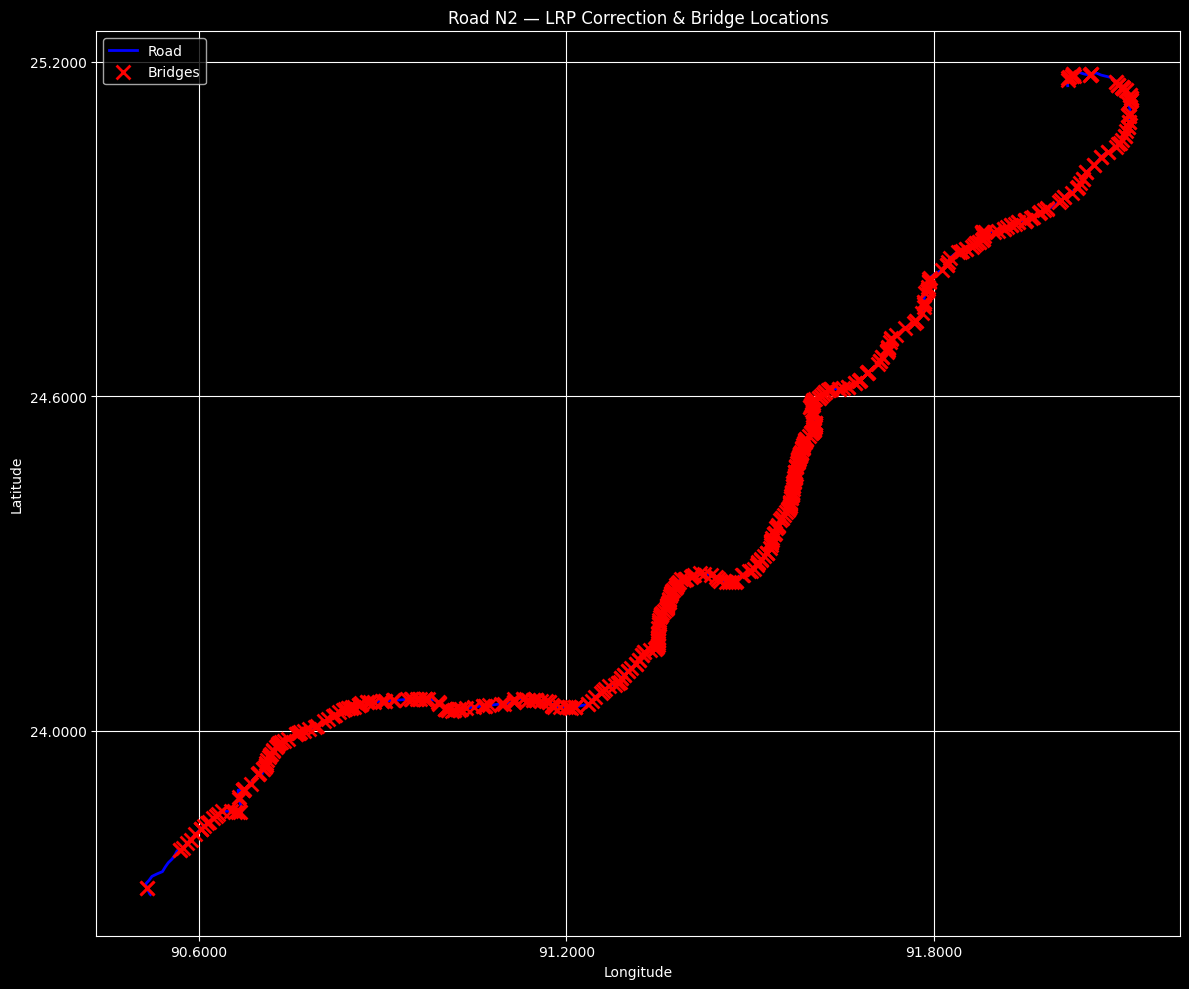

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

selected_road = "N2"

if selected_road not in road_results:
    print(f"No data found for road {selected_road}.")
else:
    viz = road_results[selected_road]
    lrp_coords        = viz['corrected_lrps']
    corrected_indices = viz['corrected_indices']
    lrp_names         = viz['lrp_names']

    # ✅ Pull bridges directly from bridges_df
    bridge_data = bridges_df[bridges_df['road'] == selected_road].copy()
    bridge_data['lon'] = pd.to_numeric(bridge_data['lon'], errors='coerce')
    bridge_data['lat'] = pd.to_numeric(bridge_data['lat'], errors='coerce')
    bridge_data = bridge_data.dropna(subset=['lon', 'lat'])

    plt.figure(figsize=(12, 10))

    # --- Blue road line ---
    plt.plot(lrp_coords[:, 0], lrp_coords[:, 1],
             color='blue', linewidth=2, label='Road', zorder=2)

    # --- Red crosses for bridges ---
    if not bridge_data.empty:
        plt.scatter(bridge_data['lon'], bridge_data['lat'],
                    color='red', marker='x', s=100, linewidths=2,
                    label='Bridges', zorder=6)

    # --- Yellow dots for corrected LRPs ---
    if len(corrected_indices) > 0:
        plt.scatter(lrp_coords[corrected_indices, 0],
                    lrp_coords[corrected_indices, 1],
                    color='yellow', edgecolors='orange', linewidths=1.2,
                    s=120, label='Corrected LRPs', zorder=7)

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Road {selected_road} — LRP Correction & Bridge Locations')
    plt.grid(True)

    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.4f}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.4f}"))

    plt.legend()
    plt.tight_layout()
    plt.show()

## Percentages for matched bridges with roads + lrp

In [6]:
import numpy as np
import pandas as pd

lrp_block = roads_df.iloc[:, 1:]   # everything after road
records = []

for _, row in roads_df.iterrows():

    road = row.iloc[0]

    values = row.iloc[1:].values

    # read in chunks of 3 → LRP / lat / lon
    for i in range(0, len(values), 3):

        lrp = values[i]

        if pd.isna(lrp):
            continue

        lat = values[i+1] if i+1 < len(values) else np.nan
        lon = values[i+2] if i+2 < len(values) else np.nan

        records.append([road, str(lrp).strip(), lat, lon])

roads_lrp_df = pd.DataFrame(
    records,
    columns=['road','LRPName','lrp_lat','lrp_lon']
)
bridges_df['LRPName'] = bridges_df['LRPName'].str.strip()
matched = bridges_df.merge(
    roads_lrp_df,
    on=['road','LRPName'],
    how='inner'
)
n_matched = len(matched)
total = len(bridges_df)

print("Matched bridges:", n_matched)
print("Total bridges:  ", total)
print("Match rate:     ", f"{n_matched/total:.2%}")


Matched bridges: 15010
Total bridges:   20353
Match rate:      73.75%


## Percentages for bridges with no roads

In [7]:
roads_in_roads = set(roads_df['road'].dropna().str.strip())
roads_in_bridges = set(bridges_df['road'].dropna().str.strip())

missing_roads = roads_in_bridges - roads_in_roads

print("Road names in bridges but NOT in roads_df:")
print(missing_roads)
print("Count of missing road names:", len(missing_roads))

bridges_with_missing_roads = bridges_df[
    bridges_df['road'].str.strip().isin(missing_roads)
]

print("Bridges whose road is not in roads_df:",
      len(bridges_with_missing_roads))

print(
    "Percentage:",
    f"{len(bridges_with_missing_roads)/len(bridges_df):.2%}"
)


Road names in bridges but NOT in roads_df:
set()
Count of missing road names: 0
Bridges whose road is not in roads_df: 0
Percentage: 0.00%


# Bridge Correction algorithm

In [8]:
roads_df['road'] = roads_df['road'].str.strip()
bridges_df['road'] = bridges_df['road'].str.strip()
bridges_df['LRPName'] = bridges_df['LRPName'].str.strip()

valid_roads = set(roads_df['road'])

bridges_df = bridges_df[
    bridges_df['road'].isin(valid_roads)
].copy()


import numpy as np
import pandas as pd

records = []

for _, row in roads_df.iterrows():

    road = row.iloc[0]
    values = row.iloc[1:].values

    for i in range(0, len(values), 3):

        lrp = values[i]

        if pd.isna(lrp):
            continue

        lat = values[i+1] if i+1 < len(values) else np.nan
        lon = values[i+2] if i+2 < len(values) else np.nan

        records.append([
            road,
            str(lrp).strip(),
            lat,
            lon
        ])

roads_lrp_df = pd.DataFrame(
    records,
    columns=['road','LRPName','lrp_lat','lrp_lon']
)


bridges_df = bridges_df.merge(
    roads_lrp_df,
    on=['road','LRPName'],
    how='left'
)

mask = bridges_df['lrp_lat'].notna() & bridges_df['lrp_lon'].notna()

bridges_df.loc[mask, 'lat'] = bridges_df.loc[mask, 'lrp_lat']
bridges_df.loc[mask, 'lon'] = bridges_df.loc[mask, 'lrp_lon']

bridges_df = bridges_df.drop(
    columns=['lrp_lat','lrp_lon']
)

print("Remaining bridges:", len(bridges_df))
print("Bridges updated from road LRP:", mask.sum())
print("Bridges kept original coords:", (~mask).sum())

Remaining bridges: 20467
Bridges updated from road LRP: 15010
Bridges kept original coords: 5457


In [9]:
def point_to_segment_distance(P, A, B):
    AP = P - A
    AB = B - A
    if np.dot(AB, AB) == 0:
        return np.linalg.norm(P - A), A
    t = np.dot(AP, AB) / np.dot(AB, AB)
    t = np.clip(t, 0, 1)
    proj = A + t * AB
    return np.linalg.norm(P - proj), proj

def build_road_lines(roads_df):
    road_lines = {}

    for road in roads_df['road'].unique():
        road_data = roads_df[roads_df['road'] == road]

        pts = []
        for _, row in road_data.iterrows():
            col_idx = 1
            while col_idx + 2 < len(row):
                lat = row.iloc[col_idx+1]
                lon = row.iloc[col_idx+2]

                if pd.notna(lat) and pd.notna(lon):
                    try:
                        pts.append([float(lon), float(lat)])
                    except:
                        pass

                col_idx += 3

        if len(pts) >= 2:
            road_lines[road] = np.array(pts, dtype=float)

    return road_lines

road_lines = build_road_lines(roads_df)
print(f"Built {len(road_lines)} road polylines")

SNAP_DIST = 25 / 111000   # 25 meters
MAX_ROAD_DIST = 1_000 / 111_000   # 10 km

snapped = 0
checked = 0
deleted = 0

to_delete = []

for idx, bridge in bridges_df.copy().iterrows():
    if pd.isna(bridge['lat']) or pd.isna(bridge['lon']):
        to_delete.append(idx)
        deleted += 1
        continue

    road = bridge['road']
    if road not in road_lines:
        to_delete.append(idx)
        deleted += 1
        continue

    P = np.array([bridge['lon'], bridge['lat']], dtype=float)
    road_line = road_lines[road]

    best_dist = np.inf
    best_proj = None

    for i in range(len(road_line)-1):
        A = road_line[i]
        B = road_line[i+1]
        d, proj = point_to_segment_distance(P, A, B)
        if d < best_dist:
            best_dist = d
            best_proj = proj

    checked += 1

    if best_dist > MAX_ROAD_DIST:
        to_delete.append(idx)
        deleted += 1
        continue

    if best_dist > SNAP_DIST:
        bridges_df.at[idx, 'lon'] = best_proj[0]
        bridges_df.at[idx, 'lat'] = best_proj[1]
        snapped += 1

# delete
bridges_df = bridges_df.drop(index=to_delete).reset_index(drop=True)

print(f"Checked {checked} bridges")
print(f"Snapped {snapped} bridges")
print(f"Deleted {deleted} bridges")

Built 876 road polylines
Checked 20467 bridges
Snapped 7 bridges
Deleted 2 bridges


## save the data to the files

In [10]:
roads_df.to_csv(
    ROADS_FILE,
    sep="\t",
    index=False,
    encoding="utf-8"
)
print("Saved output.")

Saved output.


In [11]:
bridges_df.to_excel(
    BRIDGES_FILE,
    index=False,
    sheet_name="BMMS_overview"
)
print("Saved output.")

Saved output.
